## Notebook Cell 1 — Import Libraries

Create your first notebook cell:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

___
__Understanding These Libraries__

| Library    | Purpose                |
| ---------- | ---------------------- |
| pandas     | dataset handling       |
| numpy      | numerical operations   |
| matplotlib | plotting               |
| seaborn    | advanced visualization |

___
__IMPORTANT CONCEPT__

__EDA is mostly:__

* statistics
* visualization
* pattern discovery

NOT machine learning yet.
___

# Phase 1

## Notebook Cell 2 — Load Dataset

From the repository:

In [2]:
df = pd.read_csv("data/raw/train.csv")

In [3]:
df.head()

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,basic,1916.00442,1
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,basic,1916.00442,1
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,basic,1916.00442,1
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,basic,1916.00442,1
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,basic,1916.00442,1


___
__What head() Does__

Shows first 5 rows.

Purpose:

* verify data loaded correctly
* understand columns
* understand feature meaning
* Think Like an ML Engineer
___
When you see a dataset, ask:

    What story is the data telling?

Not:

    “How fast can I train a model?”

That mindset matters.
___

## Notebook Cell 3 — Dataset Shape

In [4]:
df.shape

(36500, 13)

___
__Why Shape Matters__

You immediately understand:

* dataset size
* feature count
* possible complexity

Small data:

* risk of overfitting

Huge data:

* computational concerns
___

## Notebook Cell 4 — Column Names

In [5]:
df.columns

Index(['Store', 'Date', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Promo2'],
      dtype='object')

___
This tells:

* available features
* naming consistency
* possible target column
___

## Notebook Cell 5 — Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                36500 non-null  int64  
 1   Date                 36500 non-null  object 
 2   DayOfWeek            36500 non-null  int64  
 3   Sales                36500 non-null  float64
 4   Customers            36135 non-null  float64
 5   Open                 36500 non-null  int64  
 6   Promo                36500 non-null  int64  
 7   StateHoliday         36500 non-null  object 
 8   SchoolHoliday        36500 non-null  int64  
 9   StoreType            36500 non-null  object 
 10  Assortment           36500 non-null  object 
 11  CompetitionDistance  35770 non-null  float64
 12  Promo2               36500 non-null  int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 3.6+ MB


___
VERY IMPORTANT.
\
Example:
    int64
    float64
    object
___
__Why Data Types Matter__
\
ML models usually require:
* numeric input
\
But datasets often contain:
* text
* dates
* categories

Those need preprocessing.
___
__Beginner Insight__

If model sees:

    "Male"
    "Female"

it cannot do math directly.
\
We must encode them numerically later.
\
That happens in feature engineering phase.
___

## Notebook Cell 6 — Missing Values

In [7]:
df.isnull().sum()

Store                    0
Date                     0
DayOfWeek                0
Sales                    0
Customers              365
Open                     0
Promo                    0
StateHoliday             0
SchoolHoliday            0
StoreType                0
Assortment               0
CompetitionDistance    730
Promo2                   0
dtype: int64

___
This checks missing data.
\
Example:
| Column | Missing |
| ------ | ------- |
| Age    | 12      |
| Salary | 0       |
___
__Why Missing Values Are Dangerous__
\
Linear Regression cannot handle NaN directly.
\
Missing values can:
* crash training
* distort statistics
* reduce accuracy
___
__Real Industry Insight__

A LOT of ML work is actually:
* cleaning bad data

not building fancy models.
___

## Notebook Cell 7 — Statistical Summary

In [8]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2
count,36500.000000,36500.000000,36500.000000,36135.000000,36500.000000,36500.000000,36500.000000,35770.000000,36500.000000
mean,25.500000,4.006849,8031.337575,299.162253,0.898192,0.358685,0.199808,5443.018719,0.500000
std,14.431067,2.001727,4487.284667,176.512459,0.302400,0.479621,0.399862,2935.655458,0.500007
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,211.840567,0.000000
25%,13.000000,2.000000,5270.870000,189.000000,1.000000,0.000000,0.000000,3165.406912,0.000000
50%,25.500000,4.000000,7764.595000,284.000000,1.000000,0.000000,0.000000,5605.465962,0.500000
75%,38.000000,6.000000,10815.385000,401.000000,1.000000,1.000000,0.000000,8214.496418,1.000000
max,50.000000,7.000000,28347.840000,1319.000000,1.000000,1.000000,1.000000,9909.378114,1.000000


___
This gives:
| Metric | Meaning  |
| ------ | -------- |
| mean   | average  |
| std    | spread   |
| min    | smallest |
| max    | largest  |
___
__Understanding Standard Deviation__
\
Standard deviation tells:
    How spread out the data is

Small std:
→ values close together

Large std:
→ values vary a lot
___
__IMPORTANT ML OBSERVATION__
\
If features have wildly different scales:
\
Example:
| Feature | Range         |
| ------- | ------------- |
| Age     | 20–50         |
| Salary  | 10000–1000000 |

Some algorithms struggle.
\
Scaling becomes important later.
___


## Notebook Cell 8 — Distribution Plots

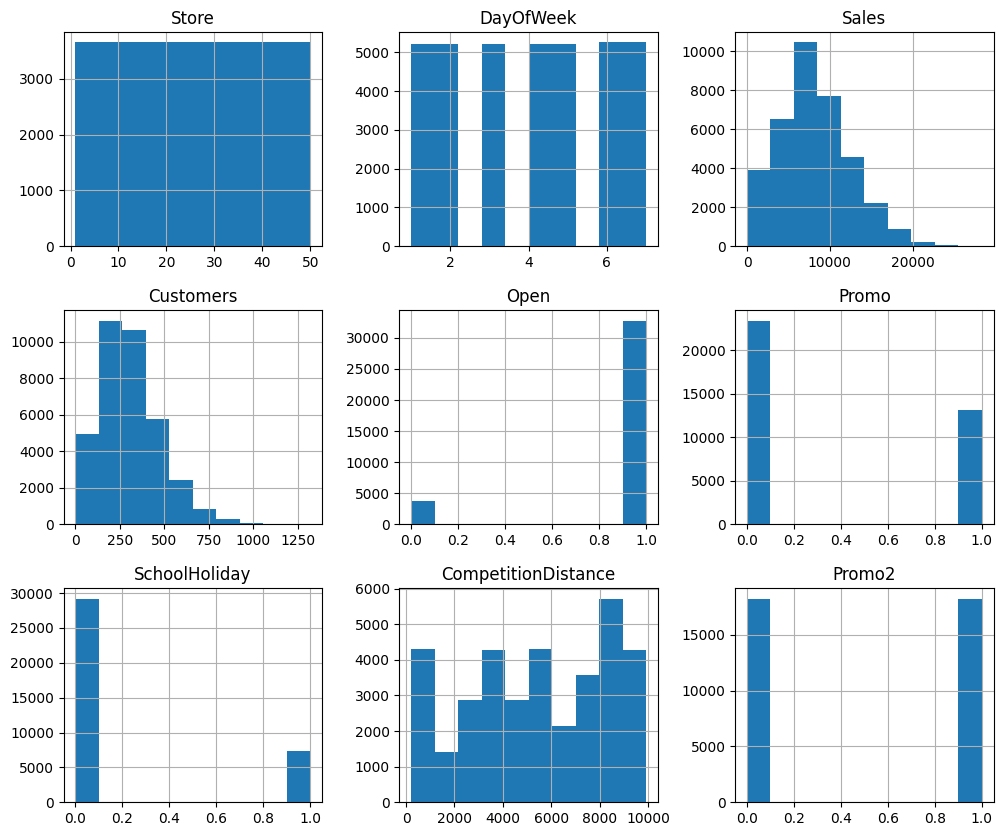

In [9]:
df.hist(figsize=(12, 10))
plt.show()

___
__Why Histograms Matter__
\
Histograms show:
* distribution shape
* skewness
* outliers
* abnormal behavior
___
__Distribution Types__
___Normal Distribution__
\
Looks like bell curve.
\
Good for many ML algorithms.
___
__Skewed Distribution__

Heavy tail on one side.

May require:

* log transform
* normalization
___

## Notebook Cell 9 — Correlation Matrix

VERY IMPORTANT for Linear Regression.

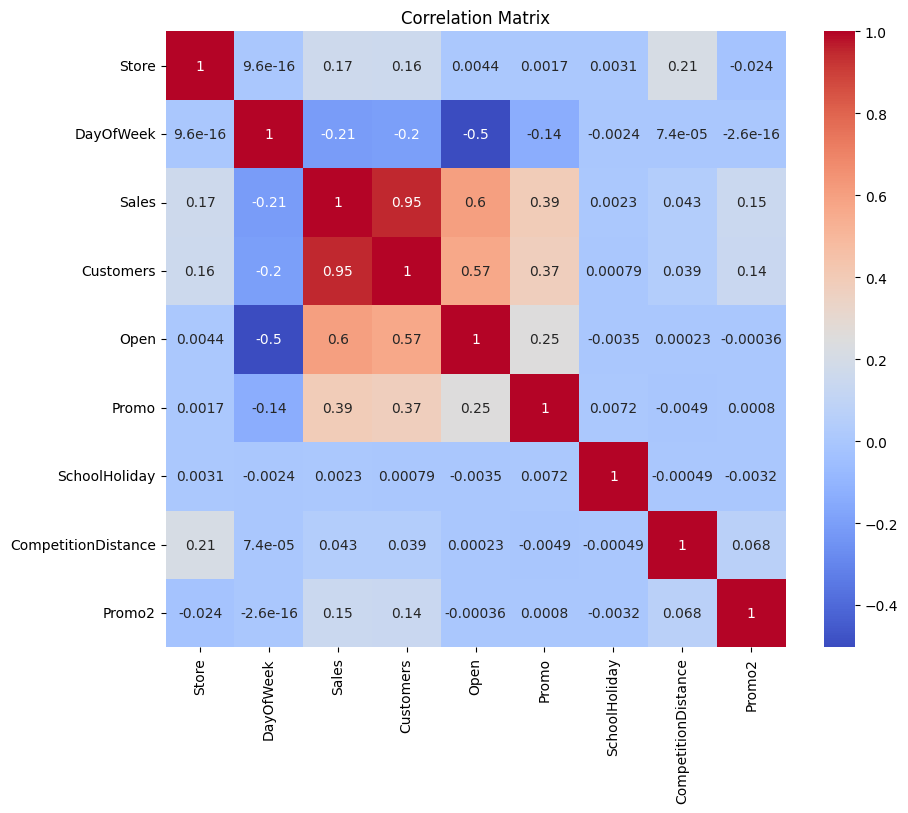

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

___
__What Correlation Means__

Correlation measures relationship strength.

Range:
$−1→1$

Correlation Interpretation
___
__Correlation Interpretation__
| Value | Meaning         |
| ----- | --------------- |
| 1     | strong positive |
| -1    | strong negative |
| 0     | no relationship |
___
__Why Correlation Matters in Regression__

Linear Regression works best when:
* features correlate with target

Weak relationships:
→ poor predictions
___

## Notebook Cell 10 — Scatter Plot

For important features:

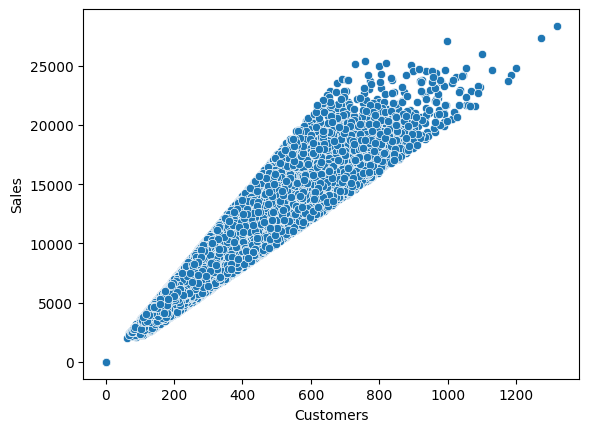

In [11]:
sns.scatterplot(x=df['Customers'], y=df['Sales'])
plt.show()

___
__What Scatter Plot Shows__

This helps detect:
* linear relationships
* clusters
* outliers
* trends
___
__VERY IMPORTANT Insight__

Linear Regression assumes:

    relationship is approximately linear

If scatter plot is curved:
→ Linear Regression may fail.
___

## Notebook Cell 11 — Outlier Detection

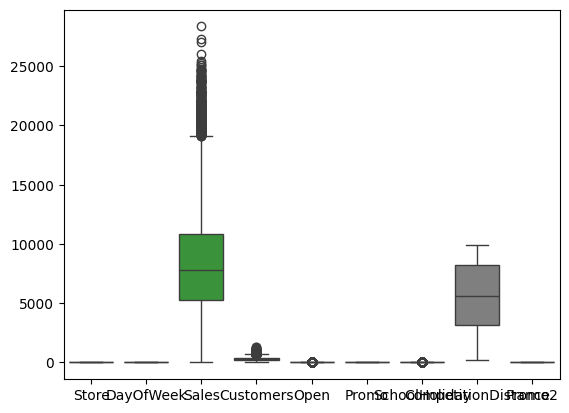

In [12]:
sns.boxplot(data=df)
plt.show()

___
__What Are Outliers?__

Unusual extreme values.

Example:
	
	Normal salaries:
		30000–100000

	One value:
		9000000

That may distort the model badly.
___
__Why Outliers Hurt Linear Regression__

Because Linear Regression minimizes squared error:

$(y - \hat{y})^2$

Large errors become MASSIVE.

Outliers dominate training.
___

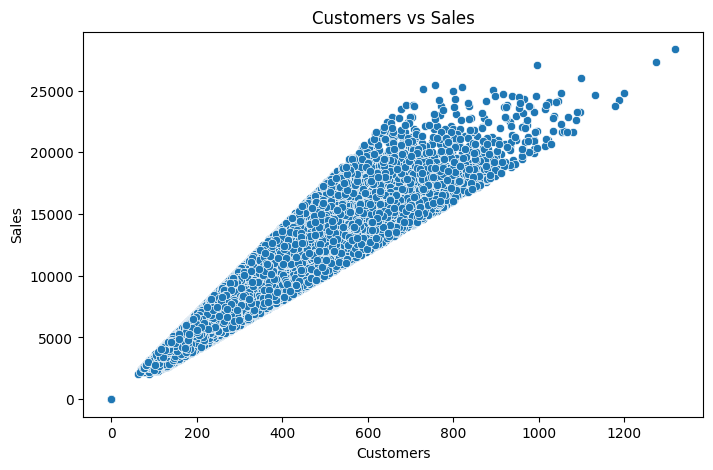

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Customers'],
    y=df['Sales']
)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

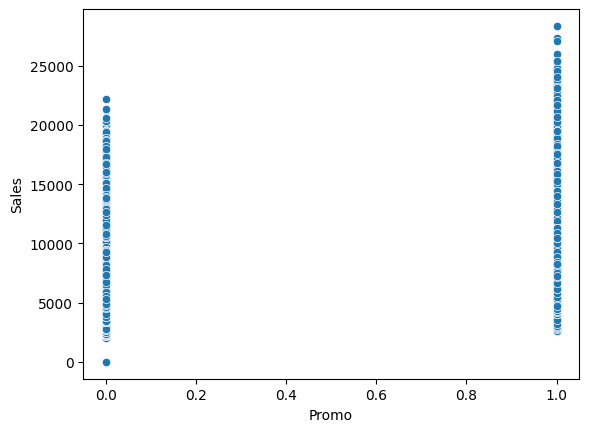

In [14]:
sns.scatterplot(x=df['Promo'], y=df['Sales'])
plt.show()

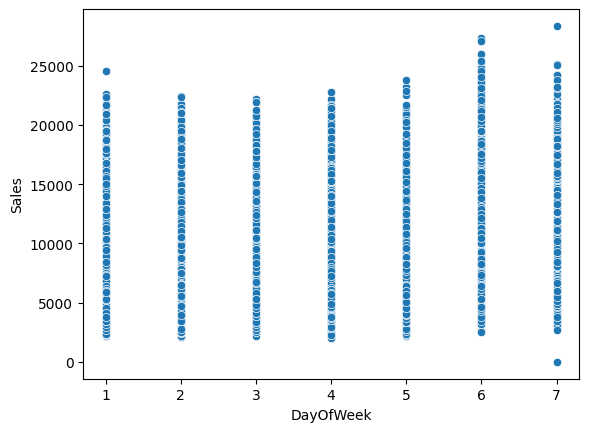

In [15]:
sns.scatterplot(x=df['DayOfWeek'], y=df['Sales'])
plt.show()

## Notebook Cell 12 — Write Observations

In [16]:
"""
EDA Observations:

1. Dataset contains retail sales data for multiple stores across 2 years.

2. Important features identified:
   - Customers
   - Promo
   - StoreType
   - Assortment
   - DayOfWeek
   - Open

3. Sales appears strongly correlated with Customers.
   Higher customer count generally leads to higher sales.

4. Promo days tend to show increased sales activity,
   indicating promotions positively influence revenue.

5. Some stores show unusually high sales values,
   suggesting potential outliers.

6. DayOfWeek affects sales patterns,
   meaning customer behavior changes across weekdays/weekends.

7. Categorical columns like:
   - StoreType
   - Assortment
   will require encoding before model training.

8. Date column contains valuable time-based information.
   Additional features like:
   - Month
   - Week
   - Year
   - Weekend
   can be engineered later.

9. Some variance in Sales increases with Customers,
   which may indicate heteroscedasticity.

10. Open = 0 rows likely correspond to closed stores,
    where Sales may be zero or near zero.

11. No major structural issues observed in the dataset,
    making it suitable for regression modeling after preprocessing.

Conclusion:
The dataset contains meaningful relationships suitable for
Linear Regression and further feature engineering.
"""

'\nEDA Observations:\n\n1. Dataset contains retail sales data for multiple stores across 2 years.\n\n2. Important features identified:\n   - Customers\n   - Promo\n   - StoreType\n   - Assortment\n   - DayOfWeek\n   - Open\n\n3. Sales appears strongly correlated with Customers.\n   Higher customer count generally leads to higher sales.\n\n4. Promo days tend to show increased sales activity,\n   indicating promotions positively influence revenue.\n\n5. Some stores show unusually high sales values,\n   suggesting potential outliers.\n\n6. DayOfWeek affects sales patterns,\n   meaning customer behavior changes across weekdays/weekends.\n\n7. Categorical columns like:\n   - StoreType\n   - Assortment\n   will require encoding before model training.\n\n8. Date column contains valuable time-based information.\n   Additional features like:\n   - Month\n   - Week\n   - Year\n   - Weekend\n   can be engineered later.\n\n9. Some variance in Sales increases with Customers,\n   which may indicate 

## Phase 2 — Feature Engineering Notebook

## Notebook Cell 13 — Copy Dataframe

In [17]:
df_features = df.copy()

___
__Explanation__

We create a copy because:

* we never modify raw data directly
* prevents accidental corruption
* easier debugging

Professional ML practice.
___

## Notebook Cell 14 — Check Data Types

In [18]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                36500 non-null  int64  
 1   Date                 36500 non-null  object 
 2   DayOfWeek            36500 non-null  int64  
 3   Sales                36500 non-null  float64
 4   Customers            36135 non-null  float64
 5   Open                 36500 non-null  int64  
 6   Promo                36500 non-null  int64  
 7   StateHoliday         36500 non-null  object 
 8   SchoolHoliday        36500 non-null  int64  
 9   StoreType            36500 non-null  object 
 10  Assortment           36500 non-null  object 
 11  CompetitionDistance  35770 non-null  float64
 12  Promo2               36500 non-null  int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 3.6+ MB


___
__Explanation__

This shows:
* column names
* datatypes
* missing values

Important because:
* ML models require numeric data
* date columns need conversion
* categorical columns need encoding
___

## Notebook Cell 15 — Convert Date Column

In [19]:
df_features['Date'] = pd.to_datetime(df_features['Date'])

___
__Explanation__

Initially:

    Date = string/text

After conversion:

    Date = datetime object

Now Python understands:
* years
* months
* weekdays
* seasonal patterns

This unlocks feature engineering.
___

## Notebook Cell 16 — Extract Year

In [20]:
df_features['Year'] = df_features['Date'].dt.year

___
__Explanation__

Extracts year from date.

Example:
| Date       | Year |
| ---------- | ---- |
| 2014-05-12 | 2014 |

Useful because:
* sales behavior changes across years
* business trends evolve over time
___

## Notebook Cell 17 — Extract Month

In [21]:
df_features['Month'] = df_features['Date'].dt.month

___
__Explanation__

Retail sales are highly seasonal.

Example:

* December → holiday shopping
* January → lower sales

Month becomes an important predictive signal.
___

## Notebook Cell 18 — Extract Day

In [22]:
df_features['Day'] = df_features['Date'].dt.day

___
__Explanation__

Captures:
* beginning/end of month behavior
* salary cycle effects
* monthly shopping trends
___

## Notebook Cell 19 — Extract Week Of Year

In [23]:
df_features['WeekOfYear'] = (df_features['Date'].dt.isocalendar().week)

___
__Explanation__

Captures weekly sales cycles.

Example:
* festival weeks
* shopping seasons
* recurring customer patterns

Very useful in retail forecasting.
___

## Notebook Cell 20 — Create Weekend Feature

In [24]:
df_features['IsWeekend'] = (df_features['DayOfWeek'].isin([6, 7]).astype(int))

___
__Explanation__

Creates:
| DayOfWeek | IsWeekend |
| --------- | --------- |
| Monday    | 0         |
| Sunday    | 1         |

Why useful?

Customer behavior changes during weekends:
* more shopping
* higher foot traffic
* different promotion effectiveness

This is business-aware feature engineering.
___

## Notebook Cell 21 — Inspect New Features

In [25]:
df_features[['Date', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend']].head()

,Date,Year,Month,Day,WeekOfYear,IsWeekend
0,2022-01-01,2022,1,1,52,1
1,2022-01-02,2022,1,2,52,1
2,2022-01-03,2022,1,3,1,0
3,2022-01-04,2022,1,4,1,0
4,2022-01-05,2022,1,5,1,0


___
Explanation

Verify:
* extracted features are correct
* no transformation errors occurred

Always validate engineered features.
___

## Notebook Cell 22 — Check Categorical Columns

In [26]:
df_features.select_dtypes(include='object').columns

Index(['StateHoliday', 'StoreType', 'Assortment'], dtype='object')

___
__Explanation__

Machine learning models cannot directly process text.

This cell identifies:
* categorical columns
* columns requiring encoding

Likely outputs:
* StoreType
* Assortment
___

## Notebook Cell 23 — One-Hot Encode Categories

In [27]:
df_features = pd.get_dummies(df_features,columns=['StoreType', 'Assortment'],drop_first=True)

___
__Explanation__

Converts categories into numeric columns.

Example:
| StoreType |
| --------- |
| A         |
| B         |

Becomes:
| StoreType_B |
| ----------- |
| 0           |
| 1           |

Required because Linear Regression works mathematically.
___
__Why drop_first=True __

Prevents:

    Dummy Variable Trap

Which causes:
* multicollinearity
* unstable regression coefficients

Important for Linear Regression.
___

## Notebook Cell 23 — Remove Original Date Column

In [28]:
df_features.drop(columns=['Date'], inplace=True)

___
Explanation

We already extracted useful time information:
* Year
* Month
* Day
* WeekOfYear

Raw date is no longer needed.
___

## Notebook Cell 24 — Check Final Dataset

In [29]:
df_features.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,IsWeekend,StoreType_b,StoreType_c,StoreType_d,Assortment_extended,Assortment_extra
0,1,6,11898.34,388.0,1,0,0,1,1916.00442,1,2022,1,1,52,1,False,True,False,False,False
1,1,7,12746.32,560.0,1,0,0,0,1916.00442,1,2022,1,2,52,1,False,True,False,False,False
2,1,1,7983.84,273.0,1,0,0,0,1916.00442,1,2022,1,3,1,0,False,True,False,False,False
3,1,2,9106.46,339.0,1,0,0,0,1916.00442,1,2022,1,4,1,0,False,True,False,False,False
4,1,3,9124.65,313.0,1,0,0,0,1916.00442,1,2022,1,5,1,0,False,True,False,False,False


___
__Explanation__

Now the dataset should contain:
* numeric columns
* encoded features
* engineered time features

This is now ML-ready data.
___

## Notebook Cell 25 — Check Final Data Types

In [30]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                36500 non-null  int64  
 1   DayOfWeek            36500 non-null  int64  
 2   Sales                36500 non-null  float64
 3   Customers            36135 non-null  float64
 4   Open                 36500 non-null  int64  
 5   Promo                36500 non-null  int64  
 6   StateHoliday         36500 non-null  object 
 7   SchoolHoliday        36500 non-null  int64  
 8   CompetitionDistance  35770 non-null  float64
 9   Promo2               36500 non-null  int64  
 10  Year                 36500 non-null  int32  
 11  Month                36500 non-null  int32  
 12  Day                  36500 non-null  int32  
 13  WeekOfYear           36500 non-null  UInt32 
 14  IsWeekend            36500 non-null  int64  
 15  StoreType_b          36500 non-null 

___
Explanation

Confirm:
* no unwanted object/string columns remain
* all features are numerical

Very important before training.
___

## Notebook Cell 26 — Correlation Matrix

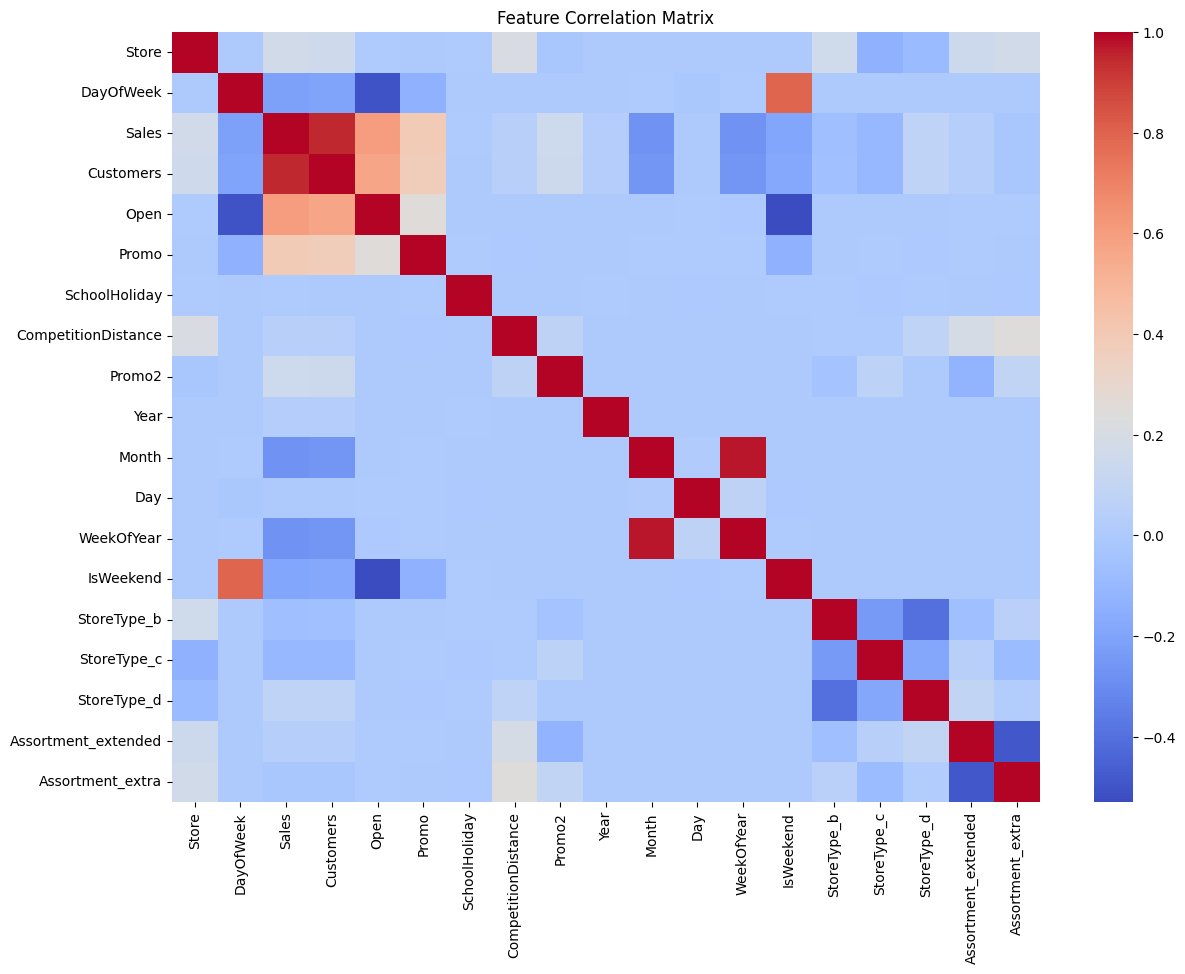

In [31]:
corr = df_features.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

___
__Explanation__

This helps identify:
* strong predictors
* weak features
* multicollinearity
* relationships with Sales

Very important before Linear Regression.
___

## Notebook Cell 27 — Sales Correlation Ranking

In [32]:
corr['Sales'].sort_values(ascending=False)

Sales                  1.000000
Customers              0.949162
Open                   0.602583
Promo                  0.389554
Store                  0.165382
Promo2                 0.147290
StoreType_d            0.076850
CompetitionDistance    0.042504
Assortment_extended    0.035225
Year                   0.030251
SchoolHoliday          0.002315
Day                   -0.000984
Assortment_extra      -0.026391
StoreType_b           -0.065039
StoreType_c           -0.103670
IsWeekend             -0.193629
DayOfWeek             -0.214002
Month                 -0.268614
WeekOfYear            -0.270804
Name: Sales, dtype: float64

___
__Explanation__

Shows:

* which features most influence Sales

Likely strong features:

* Customers
* Promo
* Open

This helps us understand feature importance.
___

## Notebook Cell 28 — Final Feature Engineering Observations

In [33]:
"""
Feature Engineering Observations:

1. Date column successfully transformed into useful time-based features.

2. Month and WeekOfYear may capture seasonal retail trends.

3. Weekend feature helps model customer behavior differences.

4. Categorical columns successfully encoded into numerical format.

5. Dataset is now machine-learning compatible.

6. Correlation analysis shows which features influence Sales most strongly.

7. Engineered features provide richer business signals for prediction.

Conclusion:
The dataset is now ready for model training and regression analysis.
"""

'\nFeature Engineering Observations:\n\n1. Date column successfully transformed into useful time-based features.\n\n2. Month and WeekOfYear may capture seasonal retail trends.\n\n3. Weekend feature helps model customer behavior differences.\n\n4. Categorical columns successfully encoded into numerical format.\n\n5. Dataset is now machine-learning compatible.\n\n6. Correlation analysis shows which features influence Sales most strongly.\n\n7. Engineered features provide richer business signals for prediction.\n\nConclusion:\nThe dataset is now ready for model training and regression analysis.\n'

## Phase 2.5 — Advanced Feature Engineering Architecture

### Notebook Cell 1 — Basic Pipeline Import

In [34]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

### Notebook Cell 2 — Load Dataset

In [35]:
df = pd.read_csv("data/raw/train.csv")

### Notebook Cell 3 — Inspect Dataset

In [36]:
df.head()

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,basic,1916.00442,1
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,basic,1916.00442,1
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,basic,1916.00442,1
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,basic,1916.00442,1
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,basic,1916.00442,1


### Notebook Cell 4 — Understand Open Stores

In [37]:
df['Open'].value_counts()

Open
1    32784
0     3716
Name: count, dtype: int64

___
__Explanation__

This helps verify:

* how many stores were closed
* how many active store records exist

Closed stores usually:

* have zero sales
* add noise to regression
___

### Notebook Cell 5 — Import sklearn Transformer Base Classes

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin

___
__Explanation__

These classes allow us to build:

    custom sklearn-compatible transformers

This is how professional ML preprocessing works.
___

### Notebook Cell 6 — Create DropClosedStores Transformer

In [39]:
class DropClosedStores(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        X = X[X['Open'] == 1]

        return X

___
__Explanation__

This transformer:

* removes rows where stores were closed

Reason:

* closed stores naturally have low/zero sales
* they distort learning

This is business-aware preprocessing.
___

### Notebook Cell 7 — Test DropClosedStores

In [40]:
dropper = DropClosedStores()

df_open = dropper.transform(df)

df_open['Open'].value_counts()

Open
1    32784
Name: count, dtype: int64

___
Explanation

Verify:

* only open stores remain

This confirms transformer works correctly.
___

### Notebook Cell 8 — Create DateFeatureExtractor

In [41]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        X['Date'] = pd.to_datetime(X['Date'])

        X['Year'] = X['Date'].dt.year

        X['Month'] = X['Date'].dt.month

        X['Day'] = X['Date'].dt.day

        X['WeekOfYear'] = (
            X['Date']
            .dt.isocalendar()
            .week
        )

        X['IsWeekend'] = (
            X['DayOfWeek']
            .isin([6, 7])
            .astype(int)
        )

        return X

___
__Explanation__

This transformer extracts:

* year
* month
* day
* week number
* weekend behavior

from raw dates.

This captures:

* seasonality
* shopping cycles
* customer patterns

Very important in retail forecasting.
___

### Notebook Cell 9 — Test DateFeatureExtractor

In [42]:
date_extractor = DateFeatureExtractor()

df_dates = date_extractor.transform(df_open)

df_dates[
    [
        'Date',
        'Year',
        'Month',
        'Day',
        'WeekOfYear',
        'IsWeekend'
    ]
].head()

,Date,Year,Month,Day,WeekOfYear,IsWeekend
0,2022-01-01,2022,1,1,52,1
1,2022-01-02,2022,1,2,52,1
2,2022-01-03,2022,1,3,1,0
3,2022-01-04,2022,1,4,1,0
4,2022-01-05,2022,1,5,1,0


___
__Explanation__

Validate:

* extracted features look correct
* transformations succeeded

Always test transformers independently.
___

### Notebook Cell 10 — Check Missing Values

In [43]:
df_dates.isnull().sum()

Store                    0
Date                     0
DayOfWeek                0
Sales                    0
Customers              330
Open                     0
Promo                    0
StateHoliday             0
SchoolHoliday            0
StoreType                0
Assortment               0
CompetitionDistance    654
Promo2                   0
Year                     0
Month                    0
Day                      0
WeekOfYear               0
IsWeekend                0
dtype: int64

___
__Explanation__

Before training:

* identify missing values
* determine imputation strategy

Missing values are common in real-world ML.
___

### Notebook Cell 11 — Create GroupMedianImputer

In [44]:
class GroupMedianImputer(BaseEstimator, TransformerMixin):

    def __init__(self, group_col, target_col):

        self.group_col = group_col
        self.target_col = target_col

    def fit(self, X, y=None):

        self.group_medians_ = (
            X.groupby(self.group_col)[self.target_col]
            .median()
        )

        return self

    def transform(self, X):

        X = X.copy()

        for group, median in self.group_medians_.items():

            mask = (
                (X[self.group_col] == group)
                &
                (X[self.target_col].isnull())
            )

            X.loc[mask, self.target_col] = median

        return X

___
__Explanation__

This transformer:

* fills missing values
* using group-specific medians

Example:
| StoreType | Customers    |
| --------- | ------------ |
| A         | median for A |
| B         | median for B |

Much smarter than global averages.
___

### Notebook Cell 12 — Test GroupMedianImputer

In [45]:
imputer = GroupMedianImputer(
    group_col='StoreType',
    target_col='Customers'
)

df_imputed = imputer.fit_transform(df_dates)

df_imputed['Customers'].isnull().sum()

np.int64(0)

In [46]:
imputer1 = GroupMedianImputer(
    group_col='Store',
    target_col='CompetitionDistance'
)

df_imputed = imputer1.fit_transform(df_dates)

df_imputed['CompetitionDistance'].isnull().sum()

np.int64(0)

___
__Explanation__

Verify:

* missing customer values are filled

This confirms imputation works.
___

### Notebook Cell 13 — Understand Leakage

In [47]:
"""
Data Leakage Example:

WRONG:
Scaling or encoding using ALL data before train-test split.

Why dangerous?
Because test data information leaks into training.

Leakage-safe pipelines prevent this issue.
"""

'\nData Leakage Example:\n\nWRONG:\nScaling or encoding using ALL data before train-test split.\n\nWhy dangerous?\nBecause test data information leaks into training.\n\nLeakage-safe pipelines prevent this issue.\n'

___
__Explanation__

This is one of the MOST IMPORTANT ML engineering concepts.

Leakage creates:

* fake accuracy
* unrealistic evaluation

Pipelines help prevent this.
___

### Notebook Cell 14 — Basic Pipeline Construction

In [48]:
pipeline = Pipeline([

    ('drop_closed', DropClosedStores()),

    ('date_features', DateFeatureExtractor()),

    ('model', LinearRegression())
])

___
Explanation

Now preprocessing + training become one system.

Flow:
   
   Raw Data
      
      ↓
   
   Drop Closed Stores
   
      ↓
   
   Extract Date Features
   
      ↓
   
   Train Model

Professional architecture.
___

### Notebook Cell 15 — View Pipeline

In [49]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_closed', ...), ('date_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


___
__Explanation__

This displays:

* pipeline structure
* ordered preprocessing steps

Useful for debugging and inspection.
___

### Notebook Cell 16 — Final Observations

In [50]:
"""
Phase 2.5 Observations:

1. Custom transformers make preprocessing reusable and modular.

2. Pipelines ensure transformations happen consistently.

3. Leakage-safe preprocessing is critical for reliable evaluation.

4. Date features capture seasonal retail behavior.

5. Removing closed stores improves regression quality.

6. Group-specific imputation is smarter than global averages.

7. Pipelines improve deployment and maintainability.

Conclusion:
The preprocessing architecture is now production-oriented
and ready for model training.
"""

'\nPhase 2.5 Observations:\n\n1. Custom transformers make preprocessing reusable and modular.\n\n2. Pipelines ensure transformations happen consistently.\n\n3. Leakage-safe preprocessing is critical for reliable evaluation.\n\n4. Date features capture seasonal retail behavior.\n\n5. Removing closed stores improves regression quality.\n\n6. Group-specific imputation is smarter than global averages.\n\n7. Pipelines improve deployment and maintainability.\n\nConclusion:\nThe preprocessing architecture is now production-oriented\nand ready for model training.\n'

In [51]:
df = df.sort_values(
    by=['Store', 'Date']
)

In [52]:
df.head()

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,basic,1916.00442,1
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,basic,1916.00442,1
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,basic,1916.00442,1
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,basic,1916.00442,1
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,basic,1916.00442,1


In [53]:
df['Sales_Lag_1'] = (
    df.groupby('Store')['Sales']
    .shift(1)
)

In [54]:
df.head()

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Sales_Lag_1
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,basic,1916.00442,1,NaN
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,basic,1916.00442,1,11898.34
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,basic,1916.00442,1,12746.32
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,basic,1916.00442,1,7983.84
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,basic,1916.00442,1,9106.46


In [55]:
for lag in [1, 7, 14]:

    df[f'Sales_Lag_{lag}'] = (
        df.groupby('Store')['Sales']
        .shift(lag)
    )

In [56]:
df.head(10)

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,basic,1916.00442,1,NaN,NaN,NaN
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,basic,1916.00442,1,11898.34,NaN,NaN
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,basic,1916.00442,1,12746.32,NaN,NaN
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,basic,1916.00442,1,7983.84,NaN,NaN
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,basic,1916.00442,1,9106.46,NaN,NaN
5,1,2022-01-06,4,12685.39,367.0,1,1,0,0,c,basic,1916.00442,1,9124.65,NaN,NaN
6,1,2022-01-07,5,9071.14,415.0,1,0,0,0,c,basic,1916.00442,1,12685.39,NaN,NaN
7,1,2022-01-08,6,17847.72,747.0,1,1,0,0,c,basic,NaN,1,9071.14,11898.34,NaN
8,1,2022-01-09,7,0.00,0.0,0,0,0,0,c,basic,1916.00442,1,17847.72,12746.32,NaN
9,1,2022-01-10,1,12825.65,379.0,1,1,0,0,c,basic,1916.00442,1,0.00,7983.84,NaN


In [57]:
df['Rolling_Mean_7'] = (

    df.groupby('Store')['Sales']

    .transform(
        lambda x:
        x.shift(1).rolling(7).mean()
    )
)

In [58]:
df['Rolling_STD_7'] = (

    df.groupby('Store')['Sales']

    .transform(
        lambda x:
        x.shift(1).rolling(7).std()
    )
)

In [59]:
df['Sales_Trend'] = (

    df['Rolling_Mean_7']
    -
    df['Sales_Lag_7']
)

In [60]:
df['Promo_Customers'] = (
    df['Promo']
    *
    df['Customers']
)

In [61]:
df['IsWeekend'] = df_features['DayOfWeek'].isin([6,7]).astype(int)

In [62]:
df['Weekend_Promo'] = (
    df['IsWeekend']
    *
    df['Promo']
)

In [63]:
df.head(10)

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14,Rolling_Mean_7,Rolling_STD_7,Sales_Trend,Promo_Customers,IsWeekend,Weekend_Promo
0,1,2022-01-01,6,11898.34,388.0,1,0,0,1,c,...,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1,0
1,1,2022-01-02,7,12746.32,560.0,1,0,0,0,c,...,1,11898.34,NaN,NaN,NaN,NaN,NaN,0.0,1,0
2,1,2022-01-03,1,7983.84,273.0,1,0,0,0,c,...,1,12746.32,NaN,NaN,NaN,NaN,NaN,0.0,0,0
3,1,2022-01-04,2,9106.46,339.0,1,0,0,0,c,...,1,7983.84,NaN,NaN,NaN,NaN,NaN,0.0,0,0
4,1,2022-01-05,3,9124.65,313.0,1,0,0,0,c,...,1,9106.46,NaN,NaN,NaN,NaN,NaN,0.0,0,0
5,1,2022-01-06,4,12685.39,367.0,1,1,0,0,c,...,1,9124.65,NaN,NaN,NaN,NaN,NaN,367.0,0,0
6,1,2022-01-07,5,9071.14,415.0,1,0,0,0,c,...,1,12685.39,NaN,NaN,NaN,NaN,NaN,0.0,0,0
7,1,2022-01-08,6,17847.72,747.0,1,1,0,0,c,...,1,9071.14,11898.34,NaN,10373.734286,1994.654520,-1524.605714,747.0,1,1
8,1,2022-01-09,7,0.00,0.0,0,0,0,0,c,...,1,17847.72,12746.32,NaN,11223.645714,3472.546466,-1522.674286,0.0,1,0
9,1,2022-01-10,1,12825.65,379.0,1,1,0,0,c,...,1,0.00,7983.84,NaN,9402.742857,5366.459873,1418.902857,379.0,0,0


In [64]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

In [65]:
numeric_df = df.select_dtypes(
    include=[np.number]
).dropna()

In [66]:
vif_data = pd.DataFrame()

vif_data['Feature'] = numeric_df.columns

vif_data['VIF'] = [

    variance_inflation_factor(
        numeric_df.values,
        i
    )

    for i in range(len(numeric_df.columns))
]

/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [67]:
vif_data.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
14,Sales_Trend,inf
10,Sales_Lag_7,inf
12,Rolling_Mean_7,inf
2,Sales,59.641117
3,Customers,46.720160
4,Open,18.655708
1,DayOfWeek,14.713386
15,Promo_Customers,13.872251
9,Sales_Lag_1,11.288900
11,Sales_Lag_14,10.870593


In [68]:
df = df.drop(columns=['Sales_Trend', 'Sales_Lag_7', 'Rolling_Mean_7'])

## Phase 4

In [69]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

In [70]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_val_score
)

In [71]:
from xgboost import XGBRegressor

In [72]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].astype('int64')

In [73]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold


class KFoldTargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        cols,
        n_splits=5,
        shuffle=True,
        random_state=42
    ):

        self.cols = cols
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):

        self.global_mean_ = y.mean()

        self.target_means_ = {}

        for col in self.cols:

            means = (
                pd.DataFrame({
                    col: X[col],
                    'target': y
                })
                .groupby(col)['target']
                .mean()
            )

            self.target_means_[col] = means

        return self

    def transform(self, X, y=None):

        X = X.copy()

        # -----------------------------
        # INFERENCE MODE
        # -----------------------------
        if y is None:

            for col in self.cols:

                X[f'{col}_target_enc'] = (

                    X[col]

                    .map(self.target_means_[col])

                    .fillna(self.global_mean_)
                )

            return X

        # -----------------------------
        # TRAINING MODE
        # -----------------------------
        kf = KFold(
            n_splits=self.n_splits,
            shuffle=self.shuffle,
            random_state=self.random_state
        )

        for col in self.cols:

            encoded_feature = pd.Series(
                index=X.index,
                dtype=float
            )

            for train_idx, val_idx in kf.split(X):

                X_train = X.iloc[train_idx]
                y_train = y.iloc[train_idx]

                X_val = X.iloc[val_idx]

                means = (
                    pd.DataFrame({
                        col: X_train[col],
                        'target': y_train
                    })
                    .groupby(col)['target']
                    .mean()
                )

                encoded_feature.iloc[val_idx] = (

                    X_val[col]

                    .map(means)

                    .fillna(self.global_mean_)
                )

            X[f'{col}_target_enc'] = encoded_feature

        return X

In [74]:
categorical_cols = [
    'Store',
    'StoreType',
    'Assortment',
    'StateHoliday'
]

In [75]:
X = df[categorical_cols]

y = df['Sales']

In [76]:
encoder = KFoldTargetEncoder(
    cols=categorical_cols
)

In [77]:
encoder.fit(X, y)

,cols,"['Store', 'StoreType', ...]"
,n_splits,5
,shuffle,True
,random_state,42


In [78]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold

In [79]:
X_encoded = encoder.transform(X, y)

In [80]:
X_encoded.head()

,Store,StoreType,Assortment,StateHoliday,Store_target_enc,StoreType_target_enc,Assortment_target_enc,StateHoliday_target_enc
0,1,c,basic,0,9173.439276,6651.883051,8013.372965,8041.951595
1,1,c,basic,0,9197.377898,6614.151237,7967.802992,8023.457826
2,1,c,basic,0,9129.597073,6638.922350,7963.572356,8035.859629
3,1,c,basic,0,9173.439276,6651.883051,8013.372965,8041.951595
4,1,c,basic,0,9107.125535,6646.260812,7950.893558,8046.030787


In [81]:
df['Store_target_enc'] = (
    X_encoded['Store_target_enc']
)
df['StoreType_target_enc'] = (
    X_encoded['StoreType_target_enc']
)
df['Assortment_target_enc'] = (
    X_encoded['Assortment_target_enc']
)
df['StateHoliday_target_enc'] = (
    X_encoded['StateHoliday_target_enc']
)

In [82]:
df = df.drop(columns=['StateHoliday','StoreType','Assortment'])

In [83]:
df.shape

(36500, 20)

In [84]:
df_dates.shape

(32784, 18)

In [85]:
df_imputed.shape

(32784, 18)

In [86]:
df.columns

Index(['Store', 'Date', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Sales_Lag_1',
       'Sales_Lag_14', 'Rolling_STD_7', 'Promo_Customers', 'IsWeekend',
       'Weekend_Promo', 'Store_target_enc', 'StoreType_target_enc',
       'Assortment_target_enc', 'StateHoliday_target_enc'],
      dtype='object')

In [87]:
imputer = GroupMedianImputer(
    group_col='StoreType_target_enc',
    target_col='Customers'
)

df= imputer.fit_transform(df)


In [88]:
competition_imputer = GroupMedianImputer(
    group_col='StoreType_target_enc',
    target_col='CompetitionDistance'
)

df = competition_imputer.fit_transform(df)

In [89]:
promo_customer_imputer = GroupMedianImputer(
    group_col='StoreType_target_enc',
    target_col='Promo_Customers'
)

df = promo_customer_imputer.fit_transform(df)

In [90]:
lag_cols = [
    'Sales_Lag_1',
    'Sales_Lag_14',
    'Rolling_STD_7'
]

for col in lag_cols:

    df[col] = (
        df.groupby('Store')[col]
        .transform(
            lambda x: x.fillna(method='bfill')
        )
    )

/var/folders/3c/9jwgdzb961j52svsdbm3nnsm0000gn/T/ipykernel_22809/2280026300.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill')


In [91]:
X = df.drop(columns=['Sales'])

y = df['Sales']

In [92]:
tscv = TimeSeriesSplit(n_splits=5)

In [93]:
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

In [94]:
lr_model = LinearRegression()

In [95]:
lr_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(np.abs(lr_scores))

[4314.16323504 3443.0017788  4339.81699081 5609.13970454 4882.07315865]


In [96]:
ridge_model = Ridge(alpha=1.0)

In [97]:
ridge_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(np.abs(ridge_scores))

[1154.89074177  901.47782658 1121.28879731 1395.75705983 1319.70868011]


/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.379817081116783e-35.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.902960058204309e-35.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8954796421070905e-35.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/macbook/

In [98]:
lasso_model = Lasso(alpha=0.1)

In [99]:
lasso_scores = cross_val_score(
    lasso_model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(np.abs(lasso_scores))

[1154.88389444  901.60747846 1121.27060036 1395.76566294 1319.7372293 ]


/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.499e+09, tolerance: 1.040e+07
  model = cd_fast.enet_coordinate_descent(
/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.914e+09, tolerance: 2.861e+07
  model = cd_fast.enet_coordinate_descent(
/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.

In [100]:
elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

In [101]:
elastic_scores = cross_val_score(
    elastic_model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(np.abs(elastic_scores))

/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.166e+09, tolerance: 1.040e+07
  model = cd_fast.enet_coordinate_descent(
/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.044e+09, tolerance: 2.169e+07
  model = cd_fast.enet_coordinate_descent(


[1235.57514038  940.29922449 1190.06478395 1473.84595476 1411.91799067]


/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/linearregression/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.199e+10, tolerance: 2.861e+07
  model = cd_fast.enet_coordinate_descent(


In [102]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [103]:
xgb_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(np.abs(xgb_scores))

[1001.54624622  675.91854868  857.25494524 1023.17426233  987.47782619]


In [104]:
def rmspe(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            np.square(
                (
                    y_true[mask] -
                    y_pred[mask]
                ) / y_true[mask]
            )
        )
    )

In [105]:
xgb_model.fit(X, y)

preds = xgb_model.predict(X)

In [106]:
score = rmspe(y, preds)

print("RMSPE:", score)

RMSPE: 0.08975339019072574


In [107]:
residuals = y - preds

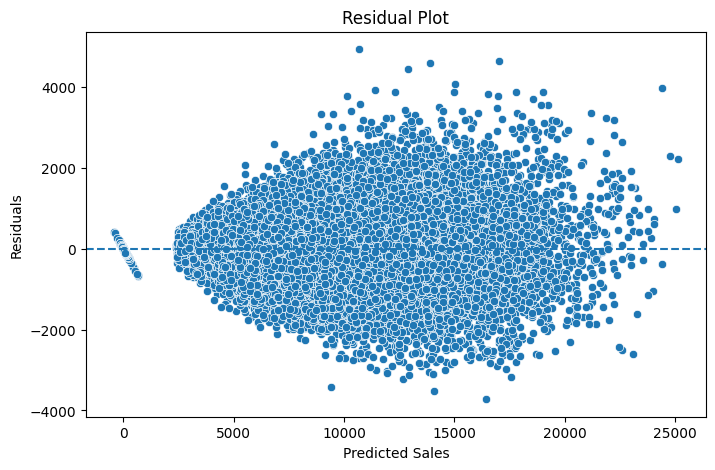

In [108]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=preds,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

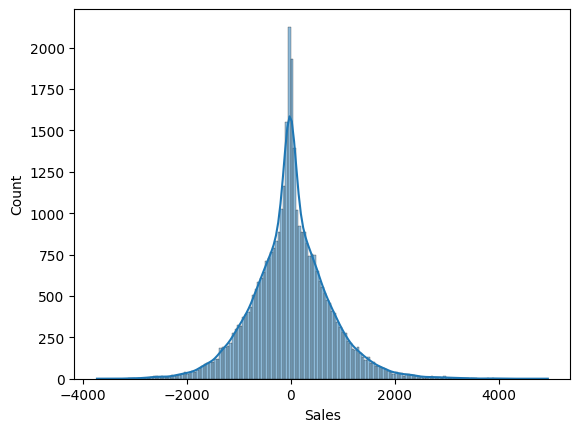

In [109]:
sns.histplot(residuals, kde=True)
plt.show()

In [110]:
results = pd.DataFrame({

    'Model': [
        'LinearRegression',
        'Ridge',
        'Lasso',
        'ElasticNet',
        'XGBoost'
    ],

    'RMSE': [

        np.abs(lr_scores).mean(),
        np.abs(ridge_scores).mean(),
        np.abs(lasso_scores).mean(),
        np.abs(elastic_scores).mean(),
        np.abs(xgb_scores).mean()
    ]
})

results

,Model,RMSE
0,LinearRegression,4517.638974
1,Ridge,1178.624621
2,Lasso,1178.652973
3,ElasticNet,1250.340619
4,XGBoost,909.074366


## Phase 5

In [111]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
X = df.drop(columns=['Sales'])

y = df['Sales']

In [113]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [114]:
X_train = X_train.values.astype(float)
X_test  = X_test.values.astype(float)

y_train = y_train.values
y_test  = y_test.values

In [115]:
class BootstrapEnsemble:

    def __init__(self,
                 n_bootstrap=30):

        self.n_bootstrap = n_bootstrap

        self.models = []

    def create_model(self):

        return Pipeline([

            ('scaler', StandardScaler()),

            ('ridge', Ridge(alpha=10))

        ])

    def fit(self, X, y):

        n = len(X)

        self.models = []

        for i in range(self.n_bootstrap):

            idx = np.random.choice(
                n,
                size=n,
                replace=True
            )

            model = self.create_model()

            model.fit(
                X[idx],
                y[idx]
            )

            self.models.append(model)

    def predict_with_uncertainty(
        self,
        X
    ):

        preds = np.stack([

            model.predict(X)

            for model in self.models

        ], axis=1)

        mean_pred = preds.mean(axis=1)

        std_pred = preds.std(axis=1)

        lower = np.percentile(
            preds,
            5,
            axis=1
        )

        upper = np.percentile(
            preds,
            95,
            axis=1
        )

        return (
            mean_pred,
            std_pred,
            lower,
            upper
        )

In [116]:
ensemble = BootstrapEnsemble(
    n_bootstrap=30
)

ensemble.fit(
    X_train,
    y_train
)

In [117]:
mean_pred, std_pred, lower, upper = (

    ensemble.predict_with_uncertainty(
        X_test
    )

)

print(
    "Mean uncertainty:",
    std_pred.mean()
)

Mean uncertainty: 37.34965646616691


In [118]:
fast_model = Pipeline([

    ('scaler', StandardScaler()),

    ('ridge', Ridge(alpha=10))

])

fast_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [119]:
accurate_model = XGBRegressor(

    n_estimators=200,

    max_depth=6,

    learning_rate=0.05,

    random_state=42

)

accurate_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [120]:
threshold = np.percentile(
    std_pred,
    80
)

print(
    "Threshold:",
    threshold
)

Threshold: 45.51807048499008


In [121]:
use_accurate = (

    std_pred >
    threshold

)

final_preds = np.zeros(
    len(X_test)
)

final_preds[use_accurate] = (

    accurate_model.predict(
        X_test[use_accurate]
    )

)

final_preds[~use_accurate] = (

    fast_model.predict(
        X_test[~use_accurate]
    )

)

In [122]:
threshold = np.percentile(
    std_pred,
    80
)

print(
    "Threshold:",
    threshold
)

Threshold: 45.51807048499008


In [123]:
use_accurate = (

    std_pred >
    threshold

)

final_preds = np.zeros(
    len(X_test)
)

final_preds[use_accurate] = (

    accurate_model.predict(
        X_test[use_accurate]
    )

)

final_preds[~use_accurate] = (

    fast_model.predict(
        X_test[~use_accurate]
    )

)

In [124]:
print(

    "Fast model %:",

    (~use_accurate).mean()*100

)

print(

    "Accurate model %:",

    use_accurate.mean()*100

)

Fast model %: 80.0
Accurate model %: 20.0


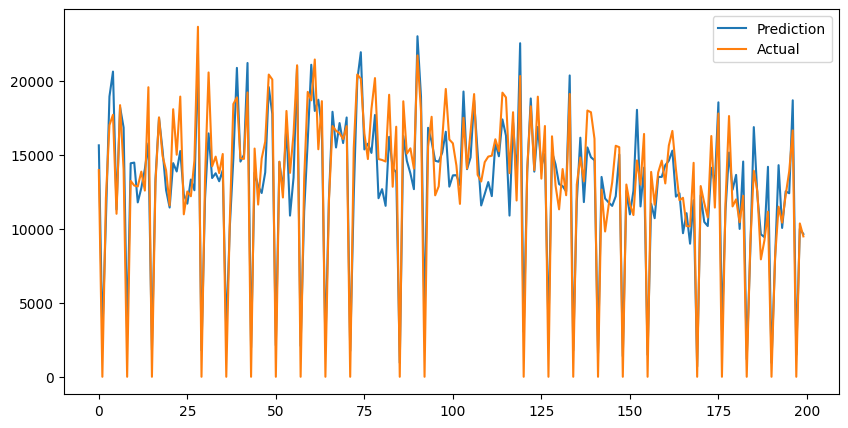

In [125]:
plt.figure(figsize=(10,5))

idx = np.arange(200)

plt.fill_between(

    idx,

    lower[:200],

    upper[:200],

    alpha=0.3

)

plt.plot(

    mean_pred[:200],

    label='Prediction'

)

plt.plot(

    y_test[:200],

    label='Actual'

)

plt.legend()

plt.show()

## Phase 6

In [126]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [127]:
def simulate_concept_drift(
    df,
    drift_start_month="2023-09",
    promo_effectiveness_drop=0.30
):

    df_drift = df.copy()

    df_drift['Date'] = pd.to_datetime(df_drift['Date'])

    mask = ((df_drift['Date'] >= drift_start_month) & (df_drift['Promo'] == 1))

    df_drift.loc[mask,'Sales'] *= (1 - promo_effectiveness_drop)

    print(
        "Drift Applied"
    )

    return df_drift

In [128]:
df_drifted = simulate_concept_drift(df)

Drift Applied


In [129]:
def compute_psi(
    reference,
    current,
    n_bins=10,
    epsilon=1e-6
):

    bins = np.nanpercentile(

        reference,

        np.linspace(
            0,
            100,
            n_bins+1
        )
    )

    bins = np.unique(
        bins
    )

    ref_counts = (

        np.histogram(
            reference,
            bins=bins
        )[0]

        + epsilon
    )

    cur_counts = (

        np.histogram(
            current,
            bins=bins
        )[0]

        + epsilon
    )

    ref_pct = ref_counts / ref_counts.sum()

    cur_pct = cur_counts / cur_counts.sum()

    psi = np.sum(

        (cur_pct - ref_pct)

        *

        np.log(
            cur_pct /
            ref_pct
        )

    )

    return psi

In [ ]:
def compute_psi_report(train_df, prod_df, features):

    results = []

    for col in features:

        psi = compute_psi(train_df[col].dropna(),prod_df[col].dropna())

        status = ("CRITICAL" if psi > 0.25 else "WARNING" if psi > 0.10 else "OK")

        results.append({ "feature": col,"PSI": round(psi,4),"status": status})

    return pd.DataFrame(results).sort_values("PSI", ascending=False)

In [ ]:
features = ['Customers', 'CompetitionDistance', 'Sales_Lag_7', 'Rolling_Mean_7', 'Promo']

In [133]:
import sys
import os

# Add the directory containing your file to the search path
# Replace with your actual folder path
sys.path.append(os.path.abspath("/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/src/features"))

# Now you can import it safely
from engineer import apply_feature_engineering


In [134]:
sys.path.append(os.path.abspath("/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/src/preprocessing"))

from pipeline import time_based_split, build_preprocessing_pipeline

# sys.path.append(os.path.abspath("/Users/macbook/Documents/Interview Notes/ML Models/Linera Regression/Linear-Regression/src/preprocessing"))

# from pipeline import time_based_split

In [135]:
df_feat        = apply_feature_engineering(df)
df_feat_drifted = apply_feature_engineering(df_drifted)

train_raw, test_raw = time_based_split(df_feat, test_months=3)
_, test_drift = time_based_split(df_feat_drifted, test_months=3)

pipeline = build_preprocessing_pipeline()
train_input = train_raw.drop(columns=["Sales", "Customers"], errors="ignore")
test_input  = test_raw.drop(columns=["Sales", "Customers"],  errors="ignore")
test_drift_input = test_drift.drop(columns=["Sales", "Customers"], errors="ignore")

X_train_df = pipeline.fit_transform(train_input, train_raw["Sales"].values)
X_train_df = X_train_df.fillna(X_train_df.median())
X_test_df  = pipeline.transform(test_input).fillna(X_train_df.median())
X_drift_df = pipeline.transform(test_drift_input).fillna(X_train_df.median())

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [ ]:
psi_report = compute_psi_report(

    X_train,

    X_test,

    features

)

psi_report

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices